In [35]:

# Utils
# ==============================================================================
import warnings

# Plot
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns


# Data
# ==============================================================================
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np



# Model
# ==============================================================================
from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
    cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier

# Metric
# ==============================================================================
from sklearn.metrics import f1_score


# **Info**
---

**@By**: Steven Bernal

**@Nickname**: Kaiziferr

**@Git**: https://github.com/Kaiziferr

# **Context**
---

A synthetic dataset is generated for a classification problem, and a stacked ensemble meta-model is implemented.

# **Config**
---

In [36]:
random_seed = 12354
warnings.filterwarnings('ignore')

# **Objetivos**
---

- Implementation of Stacking Ensemble Models

# **Data**
---


A synthetic dataset is generated for a binary classification problem

- A synthetic dataset was generated for a binary classification problem using the `make_classification` function from the `scikit-learn` library. The dataset contains 5,000 observations and 20 predictor variables. Among these variables, 8 are informative, meaning they provide relevant information for distinguishing between the two classes. Another 5 are redundant, as they are generated as linear combinations of the informative variables, while 2 are repeated features, representing duplicates of existing variables. The problem includes 2 classes, each distributed across 3 clusters, resulting in a more complex underlying data structure.

- In addition, the dataset was generated with an imbalanced class distribution, where 70% of the observations belong to the majority class and 30% to the minority class (`weights=[0.7, 0.3]`). The `class_sep=0.8` parameter defines a moderate level of class separation, allowing some overlap between the classes. Furthermore, the `flip_y=0.03` parameter introduces 3% label noise by randomly flipping class labels, simulating classification errors commonly found in real-world datasets. Finally, the `random_state=random_seed` parameter ensures reproducibility, allowing the same dataset to be generated across different runs.


In [37]:
X, y = make_classification(
    n_samples = 5000,
    n_features = 20,
    n_informative = 8,
    n_redundant = 5,
    n_repeated = 2,
    n_classes = 2,
    n_clusters_per_class = 3,
    weights = [0.7, 0.3],
    class_sep = 0.8,
    flip_y=0.03,
    random_state=random_seed
)

- The generated data were stored in a `Pandas` DataFrame, facilitating data manipulation, exploration, and analysis. The 20 predictor variables were sequentially named `x0`, `x1`, ..., `x19`, providing a clear and consistent way to identify each feature. In addition, an extra column named `target` was included to store the target variable (`y`), representing the class label assigned to each observation. This tabular structure serves as the foundation for exploratory data analysis, data preprocessing, and the training of machine learning models.


In [38]:
data = pd.DataFrame(X, columns=[f'x{i}' for i in range(X.shape[1])])
data['target'] = y

- To increase the complexity of the dataset and simulate nonlinear relationships among the predictor variables, three additional features were created through feature engineering. These derived variables were generated by applying mathematical transformations to the original features, enabling the representation of interactions and nonlinear patterns that can improve the predictive performance of machine learning models.

- The first derived feature, `x_inter_1`, was defined as the product of `x0` and `x1`, representing a multiplicative interaction between these two variables. This transformation captures joint effects that may not be identified when each feature is considered independently.

- The second derived feature, `x_inter_2`, was computed as the sum of two nonlinear transformations: the sine of `x2` and the natural logarithm of the absolute value of `x3` plus one. This feature introduces both periodic behavior and logarithmic scaling, simulating more complex relationships commonly observed in real-world data.

- Finally, the third derived feature, `x_inter_3`, was constructed by squaring `x4` and subtracting the product of `x5` and `x6`. This transformation combines a quadratic effect with an interaction between variables, further increasing the nonlinear complexity of the dataset.


In [39]:
data['x_inter_1'] = data['x0'] * data['x1']
data['x_inter_2'] = np.sin(data['x2']) + np.log(np.abs(data['x3'])+1)
data["x_inter_3"] = data["x4"] ** 2 - data["x5"] * data["x6"]

A new variable, rule_feature, was created by evaluating a logical rule based on variables x7 and x8. This variable was assigned a value of 1 when x7 > 0.5 and x8 < -0.5 simultaneously; otherwise, it was assigned a value of 0. Thus, the feature was represented as a binary variable derived from the conjunction of these two conditions.

In [40]:
data["rule_feature"] = ((data["x7"] > 0.5) & (data["x8"] < -0.5)).astype(int)

Five random noise variables (noise_0 to noise_4) were added, each generated from a standard normal distribution with a mean of 0 and a standard deviation of 1. These features do not contain any genuine predictive information; instead, they were introduced to increase the complexity of the dataset and to evaluate the ability of the stacking models to identify and mitigate the influence of irrelevant variables during the learning process.

In [41]:
for i in range(5):
    data[f"noise_{i}"] = np.random.normal(0, 1, size=len(data))

- A variable named fake_signal was generated by combining the target variable with a random noise component. Specifically, the target values were multiplied by a random factor uniformly sampled between 0.3 and 0.7, after which Gaussian noise with a mean of 0 and a standard deviation of 0.5 was added. This feature was introduced to simulate a variable with a partial relationship to the target, enabling the evaluation of the stacking models' ability to identify predictive signals in the presence of random variability.

In [42]:
data["fake_signal"] = data["target"] * np.random.uniform(0.3, 0.7, size=len(data)) \
                    + np.random.normal(0, 0.5, size=len(data))


The resulting dataset consisted of 5,000 observations and 31 columns, of which 30 corresponded to predictor variables and one to the target variable. The predictor variables included both original features and derived and synthetic features, designed to represent different levels of predictive relevance, noise, and feature interactions.

In [43]:
print(data.shape)
data.head()

(5000, 31)


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x_inter_1,x_inter_2,x_inter_3,rule_feature,noise_0,noise_1,noise_2,noise_3,noise_4,fake_signal
0,-2.192350,-1.305161,0.174367,0.957296,-1.483324,1.934409,-0.044956,1.637004,0.198217,0.527609,...,2.861369,0.845048,2.287215,0,-0.095602,1.051987,-0.948007,0.175031,-0.061118,0.679300
1,8.069522,-1.407020,0.368845,-0.677404,0.048223,-4.005198,-1.217841,0.243767,2.411555,1.359505,...,-11.353977,0.877786,-4.875371,0,-1.405722,1.564267,0.244105,-0.800474,-0.922081,-0.667050
2,-4.013321,0.946147,-3.518407,2.929394,4.075008,0.050887,-0.084859,1.228706,-2.357691,-1.621329,...,-3.797193,1.736446,16.610012,1,-0.697224,0.028993,-0.392609,-0.220096,-0.270754,0.122658
3,-4.681681,1.824917,3.615981,-0.148945,1.714807,4.623962,-0.851881,0.669905,-1.198105,-0.998399,...,-8.543681,-0.317950,6.879630,1,-0.347358,1.596904,0.334992,-0.875731,-0.672799,0.844918
4,-0.605338,-1.440976,-3.076663,4.306161,-1.575166,-3.769483,0.309818,1.999976,1.164503,-0.252134,...,0.872277,1.603984,3.649004,0,0.149283,-1.407657,0.642671,-0.201396,0.827816,-0.932537


# **Data Split**
---

In [44]:
X = data.drop(columns = ['target'])
y = data['target']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=random_seed)

# **Model**
---

- As base models in the stacking scheme, a logistic regression model, a random forest, a support vector machine, and a decision tree were used. Since the objective of the study was to develop a proof of concept to evaluate the behavior of the stacking architecture, the models were mostly implemented using their default hyperparameters, without performing extensive optimization or hyperparameter tuning. This decision allowed the analysis to focus on the performance of the ensemble method rather than on maximizing the individual performance of each base model.

In [46]:
base_model = [
    ('lr', LogisticRegression(max_iter=1000)),
    ("rf", RandomForestClassifier(n_estimators=200, random_state=random_seed)),
    ("svm", SVC(probability=True)),
    ('tree', DecisionTreeClassifier(random_state=random_seed))
]

In [47]:
data.columns

Index(['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10',
       'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'target',
       'x_inter_1', 'x_inter_2', 'x_inter_3', 'rule_feature', 'noise_0',
       'noise_1', 'noise_2', 'noise_3', 'noise_4', 'fake_signal'],
      dtype='object')

- Model performance was evaluated using a cross-validation scheme independent of the stacking process. Specifically, a stratified 10-fold cross-validation strategy was applied, repeated three times to reduce the variance of the estimates. This procedure provided a more robust measure of model performance across different data splits, ensuring the preservation of class proportions in each fold.

- Additionally, performance was assessed using the F1-score metric, which is appropriate for classification problems where a balance between precision and recall is required. This evaluation setup was used to analyze the overall model performance independently of the internal validation within the stacking framework, with the aim of assessing its stability across different data partitions

In [48]:
def evalute_model(model, X, y):
  cv = RepeatedStratifiedKFold(
      n_splits = 10,
      n_repeats = 3,
      random_state = random_seed
  )
  scores = cross_val_score(model, X, y, scoring='f1', n_jobs=-1, error_score='raise')
  return scores

- The base models were individually trained and evaluated in order to establish a baseline for subsequent comparison with the stacking model. To this end, a stratified cross-validation scheme was applied, enabling the estimation of each model’s performance across different training set partitions. Each model was evaluated using the F1-score metric, and the results were recorded along with their respective means and standard deviations, allowing for the analysis of both average performance and stability.

- This procedure aims to evaluate whether the model stacking strategy improves performance compared to individual models, while maintaining a consistent evaluation under the same cross-validation framework.

In [49]:
results, names = {}, []
for name, model in base_model:
  scores = evalute_model(model, X_train, y_train)
  results[name] = scores
  names.append(name)
  print('>%s %.3f (%.3f)' % (name, np.mean(scores), np.std(scores)))

>lr 0.583 (0.016)
>rf 0.722 (0.039)
>svm 0.739 (0.020)
>tree 0.598 (0.024)


- The results show clear differences in the performance of the base models, both in terms of average performance and stability across cross-validation folds.

- First, the logistic regression model (lr) achieved an average F1-score of 0.574 with a standard deviation of 0.021, indicating relatively low performance compared to the other models, although with moderate variability. This suggests that its ability to capture non-linear relationships in the data is limited.

- The decision tree (tree) showed a similar average performance (0.586) but the lowest variability (0.016), indicating that, although its performance is low, it is the most stable model among those evaluated.

- On the other hand, the random forest (rf) achieved significantly better performance, with an average F1-score of 0.725 and a standard deviation of 0.035. This improvement reflects the advantage of ensemble-based tree methods over a single decision tree, although with slightly higher variability across folds.

- Finally, the support vector machine (svm) was the best-performing model, with an average F1-score of 0.732 and a standard deviation of 0.021, indicating a good balance between predictive performance and stability.

- Overall, the results indicate that ensemble-based and margin-based models (rf and svm) clearly outperform simpler models (lr and tree). This comparison establishes a solid baseline for evaluating whether the stacking model can subsequently surpass the performance of the best individual model.

In [50]:
results

{'lr': array([0.56674473, 0.5764411 , 0.58571429, 0.61111111, 0.57274827]),
 'rf': array([0.68780488, 0.67669173, 0.77448747, 0.75943396, 0.71058824]),
 'svm': array([0.74074074, 0.70761671, 0.76777251, 0.75      , 0.72727273]),
 'tree': array([0.57654076, 0.5631929 , 0.62124248, 0.6035503 , 0.62474645])}

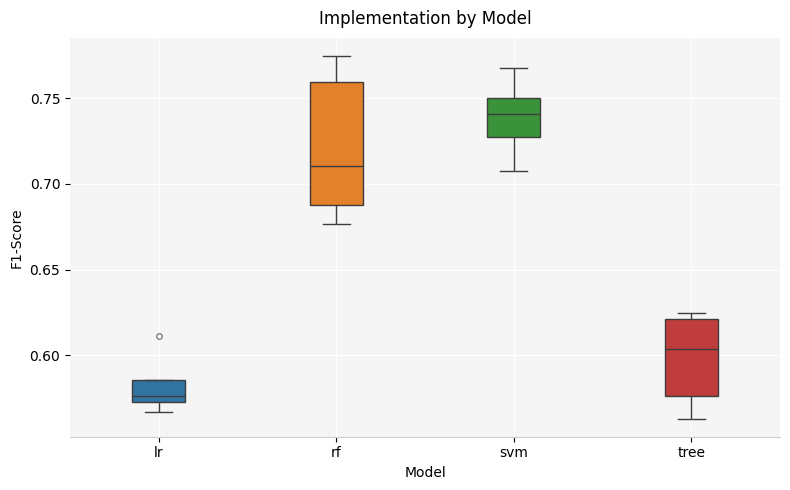

In [51]:
plot_box(results, title="Implementation by Model", palette=None, labels=("Model", "F1-Score"))
plt.tight_layout()
plt.show()

**SVM (Best Overall Performance)**

- It has the highest median (~0.73).
- Its scores are fairly tightly clustered, indicating good stability across the evaluation splits.
- It has a high-performing outlier, suggesting that in one data split it achieved particularly strong performance (~0.78).

Conclusion: It provides the best balance between performance and consistency.


**Random Forest (RF)**

- It achieves the second-best overall performance.
- Its median score is approximately 0.69–0.70.
- Its performance exhibits greater variability than SVM, indicating that it is more sensitive to the particular data splits used during evaluation.
- It reaches high scores (around 0.76–0.77) but also shows lower performance on some folds.

Conclusion: It is a strong-performing model, but less stable than SVM in this setting.


**Logistic Regression (LR)**

- It exhibits the lowest overall performance.
- Its median score is approximately 0.54–0.55.
- It shows very little variability, indicating that its performance is consistently low across the evaluation folds, with neither substantial improvements nor significant declines.

Conclusion: It is a stable model, but with limited predictive capability.

**Decision Tree**

- It achieves slightly better performance than Logistic Regression, with a median score of approximately 0.59.
- Its performance is highly consistent, exhibiting little variability across the evaluation folds.
However, it does not effectively capture complex patterns in the data.

Conclusion: It is a simple and consistent model, but its predictive performance is limited.

---
---

There are already reasonably strong baseline models, particularly SVM and Random Forest, creating a favorable setting in which the stacking ensemble may achieve a modest improvement in predictive performance or, at the very least, provide more stable results.

In [52]:
base_model

[('lr', LogisticRegression(max_iter=1000)),
 ('rf', RandomForestClassifier(n_estimators=200, random_state=12354)),
 ('svm', SVC(probability=True)),
 ('tree', DecisionTreeClassifier(random_state=12354))]

# **Stacking Model Implementation**
---

- The stacking model is defined by adding the list of base models as input estimators. These base learners include Logistic Regression, Random Forest, Support Vector Machine, and Decision Tree, which will independently generate predictions that will later be combined by the stacking architecture.

- The final estimator is defined as a Logistic Regression model, which acts as the **meta-model**. This meta-model receives the predictions generated by the base learners and learns how to combine them to produce the final output prediction.

- After defining the stacking classifier, it is added to the list of models together with the individual base models, allowing the performance of each standalone algorithm to be compared against the ensemble stacking approach.

In [53]:
model_stacking = StackingClassifier(
  estimators = base_model,
  final_estimator = LogisticRegression(),
)

models = base_model + [('model_stacking', model_stacking)]
models

[('lr', LogisticRegression(max_iter=1000)),
 ('rf', RandomForestClassifier(n_estimators=200, random_state=12354)),
 ('svm', SVC(probability=True)),
 ('tree', DecisionTreeClassifier(random_state=12354)),
 ('model_stacking',
  StackingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000)),
                                 ('rf',
                                  RandomForestClassifier(n_estimators=200,
                                                         random_state=12354)),
                                 ('svm', SVC(probability=True)),
                                 ('tree',
                                  DecisionTreeClassifier(random_state=12354))],
                     final_estimator=LogisticRegression()))]

- The performance of each model is evaluated by iterating over the list of defined models. For each model, the evaluation function is executed using the training data (`X_train`, `y_train`) to obtain the corresponding validation scores.

- The obtained scores are stored in the `results` dictionary, where each model name is associated with its evaluation metrics. At the same time, the model names are collected in the `names` list to facilitate later comparison and visualization.

- For each model, the mean and standard deviation of the obtained scores are calculated and displayed. The mean value represents the average performance of the model across the evaluation process, while the standard deviation provides information about the variability and stability of the results.


In [54]:
results, names = {}, []
for name, model in models:
  scores = evalute_model(model, X_train, y_train)
  results[name] = scores
  names.append(name)
  print('>%s %.3f (%.3f)' % (name, np.mean(scores), np.std(scores)))

>lr 0.583 (0.016)
>rf 0.722 (0.039)
>svm 0.739 (0.020)
>tree 0.598 (0.024)
>model_stacking 0.772 (0.027)


- The boxplot summarizes the performance distribution of each evaluated model across the validation process. Each box represents the variability of the obtained scores, where the central line indicates the median performance, the box represents the interquartile range, and the whiskers show the spread of the results. Outliers correspond to individual evaluations with performance values significantly different from the remaining scores.

- The results show that the individual models present different levels of predictive performance. Logistic Regression (`lr`) achieves the lowest average score, with values around 0.55, indicating a limited ability to capture the underlying patterns in the data. Random Forest (`rf`) and Support Vector Machine (`svm`) provide better performance, reaching average scores above 0.70, although with some variability across the validation folds.

- The Decision Tree model (`tree`) shows lower performance compared with the other tree-based ensemble approach, with scores close to 0.60, suggesting that a single decision tree may not be sufficient to generalize well on this dataset.

- The Stacking model (`model_stacking`) achieves the highest overall performance, with an average score around 0.77 and a relatively stable distribution. This indicates that combining the predictions from multiple heterogeneous base learners allows the meta-model to capture complementary information and improve predictive performance compared with the individual classifiers.

- Overall, the stacking approach provides the best trade-off between predictive accuracy and stability, demonstrating the benefit of combining different learning algorithms through an ensemble strategy.

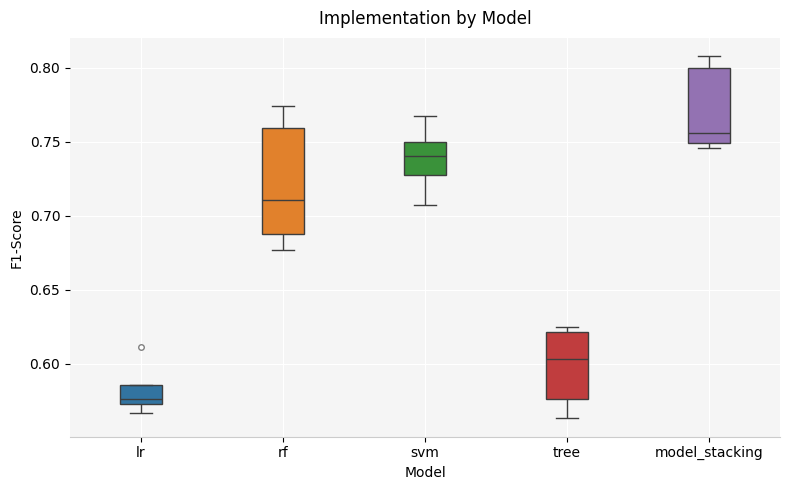

In [55]:
plot_box(results, title="Implementation by Model", palette=None, labels=("Model", "F1-Score"))
plt.tight_layout()
plt.show()

- Once the stacking model has been evaluated and selected, it is trained using the complete training dataset (`X_train`, `y_train`).

In [57]:
model_stacking.fit(X_train, y_train)

StackingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000)),
                               ('rf',
                                RandomForestClassifier(n_estimators=200,
                                                       random_state=12354)),
                               ('svm', SVC(probability=True)),
                               ('tree',
                                DecisionTreeClassifier(random_state=12354))],
                   final_estimator=LogisticRegression())

- After training, the fitted model is used to generate predictions on the unseen test dataset (`X_test`).



In [58]:
y_pred = model_stacking.predict(X_test)

- The final evaluation of the stacking classifier on the test dataset results in an **F1-score of approximately 0.761**.

In [59]:
f1_score(y_test, y_pred)

0.7610619469026548

- This indicates that the model achieves a good balance between precision and recall when predicting the target classes on unseen data. The F1-score confirms that the stacking approach is able to generalize beyond the training dataset by effectively combining the predictions from the different base learners through the meta-model.

- Compared with the individual model evaluation results, the stacking ensemble provides competitive predictive performance, demonstrating the benefit of combining multiple learning algorithms instead of relying on a single classifier.

# **Utils**
---

In [ ]:
def plot_box(
    data,
    x=None,
    y=None,
    hue=None,
    title=None,
    whis=1.5,
    ax=None,
    palette="Set1",
    width=0.3,
    linewidth=1,
    labels:tuple=("EjeX", "EjeY")):
  """
    Generate a boxplot using Seaborn with a ggplot-inspired style.

    Parameters
    ----------
    data : pandas.DataFrame
        Input DataFrame containing the data to be plotted.

    x : str, optional
        Column name for the categorical variable (x-axis grouping).
        Default: None.

    y : str, optional
        Column name for the numerical variable (y-axis).
        Default: None.

    hue : str, optional
        Column name for subgroup coloring within each x category.
        Default: None.

    title : str, optional
        Title of the plot.
        Default: None.

    whis : float, optional
        Whisker length as a proportion of the IQR beyond the box edges.
        Equivalent to matplotlib's whis parameter.
        Default: 1.5.

    ax : matplotlib.axes.Axes, optional
        Axes object to draw the plot on. If None, a new figure and axes
        are created automatically.
        Default: None.

    palette : str, optional
        Color palette for the boxes. Accepts any valid Seaborn or
        matplotlib palette name (e.g. 'Set1', 'Set2', 'tab10').
        Default: 'Set1'.

    width : float, optional
        Width of the boxes. Values between 0.2 and 0.6 recommended.
        Default: 0.3.

    linewidth : float, optional
        Width of the box borders and whisker lines.
        Default: 1.

    Returns
    -------
    matplotlib.axes.Axes
        Axes object containing the boxplot. Can be passed directly
        to another subplot via the ax parameter.
  """

  if ax is None:
      fig, ax = plt.subplots(figsize=(8, 5))

  sns.boxplot(
      data=data,
      x=x,
      y=y,
      hue=hue,
      whis=whis,
      ax=ax,
      palette=palette,
      width=width,
      linewidth=linewidth,
      flierprops=dict(
          marker="o",
          markerfacecolor="white",
          markeredgecolor="gray",
          markersize=4,
          linewidth=0.8
      )
  )

  ax.set_facecolor("#f5f5f5")
  ax.grid(True, color="white", linewidth=0.8)
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  ax.spines["left"].set_visible(False)
  ax.spines["bottom"].set_color("#cccccc")

  if title:
      ax.set_title(title, fontsize=12, pad=10)

  if labels:
    ax.set_xlabel(labels[0], fontsize=10)
    ax.set_ylabel(labels[1], fontsize=10)

  return ax